In this notebook we comapre k-means clustering on CLIP embeddings of a dataset with k-means clustering on the raw pixel features of the images in the Bird dataset. <br>
We hypothesize that the clusters formed from the CLIP embeddings would represent higher semantic similarities pertaining to birds, e.g., similarity based on species, habitat, beak shape, size, etc. <br>
On the other hand, we expect the clusters formed from the raw pixel vectors to be grouped based on more high-level similarities in the features of the images, e.g., similiarity in the dominant colors of the images, the brightness in each image, etc. <br> 
(experimented by Dhanashree, updated by Megha with Silhouette Scoring rather than Elbow method)

In [1]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from PIL import Image
import random

## Clustering of CLIP embeddings

In [2]:
# Load birds_emb. 
birds_emb = np.load('/home/d4205992-6e79-432d-bc8b-0c0503a40624/COGS118B_FinalProject/birds_emb.npy')

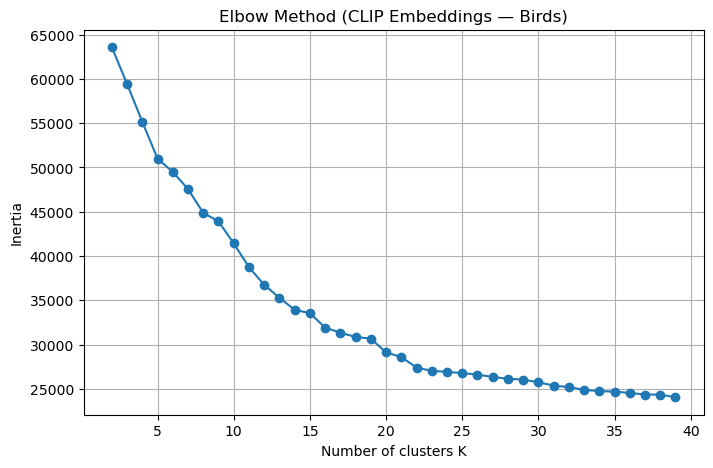

In [12]:
# Plotting Elbow curve to find a god estimate for number of clusters. 
inertias = [] # Sum of squared distances of each data point to its closest cluster center.
K_range = range(2, 40)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(birds_emb)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker="o")
plt.title("Elbow Method (CLIP Embeddings — Birds)")
plt.xlabel("Number of clusters K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

From this graph, we see that **20** may be a good estimate for the number of clusters, but let's try using the Silhouette Score instead...(generally better than the elbow method because it provides an objective numerical measure of cluster quality rather than requiring subjective visual interpretation of where the "elbow" is. While the elbow method only shows diminishing returns in variance reduction, the Silhouette Score actually measures how well-separated and cohesive clusters are, and can identify poor clustering through negative scores)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=2, silhouette=0.0813


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=3, silhouette=0.0996


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


...

K=27, silhouette=0.2168


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=28, silhouette=0.1733


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=29, silhouette=0.1853


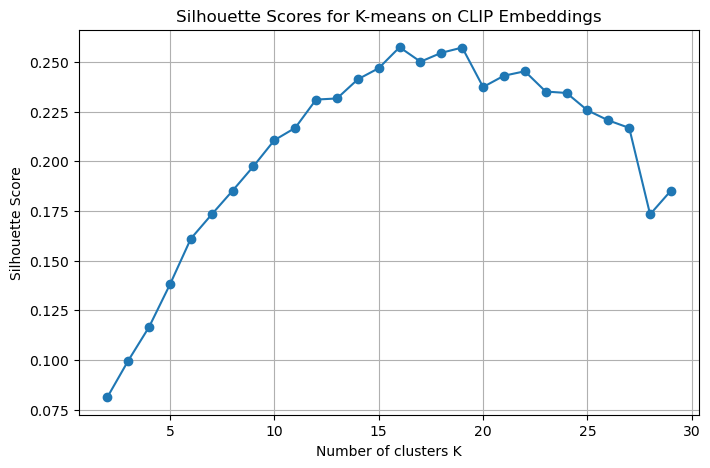


 Best K = 16 with score = 0.2575


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# embeddings: your (N, D) CLIP embedding matrix
# Ks: the range of cluster numbers
Ks = range(2, 30)
sil_scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(birds_emb)
    score = silhouette_score(birds_emb, labels)
    sil_scores.append(score)
    print(f"K={k}, silhouette={score:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(Ks, sil_scores, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-means on CLIP Embeddings")
plt.grid(True)
plt.show()
best_k = Ks[np.argmax(sil_scores)]
best_score = max(sil_scores)

print(f"\n Best K = {best_k} with score = {best_score:.4f}")

In [7]:
best_k_clip = 16

# Train k-means on CLIP embeddings.
kmeans_clip = KMeans(n_clusters=best_k_clip, random_state=0)
clip_clusters = kmeans_clip.fit_predict(birds_emb)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


## Clustering for Pixel space 

In [10]:
# Same function as seen in the main notebook. 
def get_all_images_pathlib(root_folder):
    root_path = Path(root_folder)
    images = []
    
    for file_path in root_path.rglob('*'):
        if file_path.suffix.lower() == '.jpg':
            images.append(str(file_path))
    
    return images

In [11]:
birds_folder = '/home/d4205992-6e79-432d-bc8b-0c0503a40624/COGS118B_FinalProject/Birds'
birds = get_all_images_pathlib(birds_folder)
print(f"Found {len(birds)} images")

Found 333 images


In [12]:
def load_pixel_vectors(image_paths, size=(128,128)):
    pixel_vectors = []
    for p in image_paths:
        img = Image.open(p).convert("RGB").resize(size)
        arr = np.array(img).flatten()
        pixel_vectors.append(arr) # Add the vector for each image.
    return np.array(pixel_vectors)

pixel_data = load_pixel_vectors(birds) # This contains the pixel data for the Birds images. 
print("Pixel data shape:", pixel_data.shape)

Pixel data shape: (333, 49152)


In [13]:
# Reduce the dimentionality of the pixel features using PCA.
# WHY IS THIS IMPORTANT? -> Makes the clusters more stable.
# The sklearn documentation also mentions that for very high dimensionality, k-means performance is impacted. 
# We do not resize to a very small size to preserve the details of the image. 

pca_pixels = PCA(n_components = 50)   
pixel_pcs = pca_pixels.fit_transform(pixel_data)

print("PCA pixel feature shape:", pixel_pcs.shape)

PCA pixel feature shape: (333, 50)


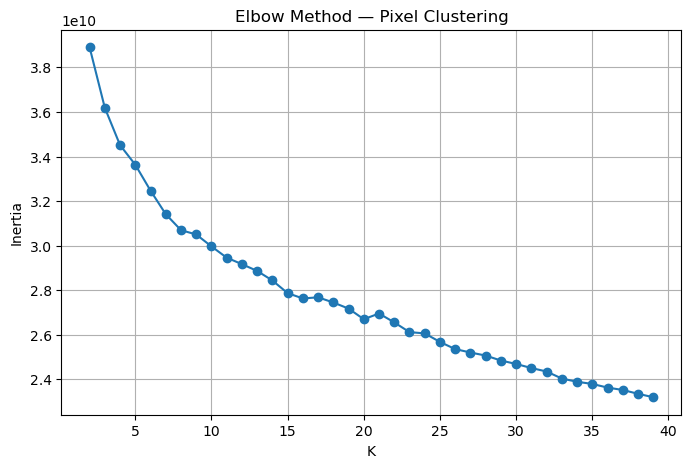

In [18]:
# Plot the elbow curve
# Similar to what we did earlier.

K_range = range(2, 40)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(pixel_pcs)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Method — Pixel Clustering")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=2, silhouette=0.1690


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=3, silhouette=0.0977


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


...

K=27, silhouette=0.0506


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=28, silhouette=0.0371


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


K=29, silhouette=0.0428


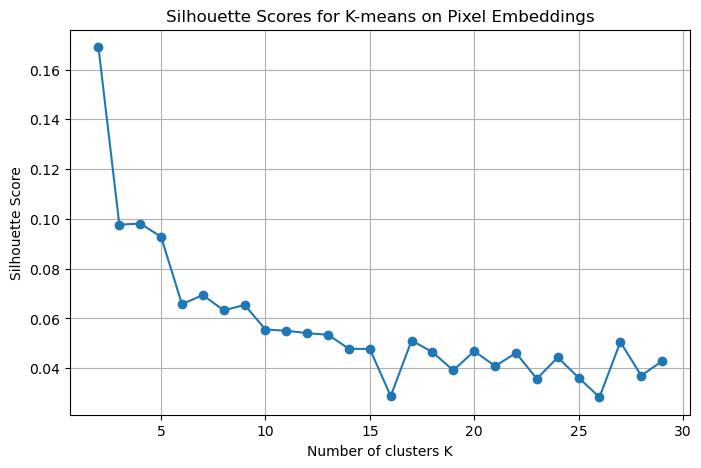


 Best K = 2 with score = 0.1690


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# embeddings: your (N, D) CLIP embedding matrix
# Ks: the range of cluster numbers
Ks = range(2, 30)
sil_scores = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixel_pcs)
    score = silhouette_score(pixel_pcs, labels)
    sil_scores.append(score)
    print(f"K={k}, silhouette={score:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(Ks, sil_scores, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for K-means on Pixel Embeddings")
plt.grid(True)
plt.show()
best_k = Ks[np.argmax(sil_scores)]
best_score = max(sil_scores)

print(f"\n Best K = {best_k} with score = {best_score:.4f}")

In [31]:
best_k_pixel = 2

# Train k-means on pixel data.
kmeans_pixel = KMeans(n_clusters=best_k_pixel, random_state=0)
pixel_clusters = kmeans_pixel.fit_predict(pixel_data)

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [25]:
# We would like to see how the bird images were grouped differently.
# To do this we define a function which lets us display "n" number of images from a cluster of or choice.
# We refer to a cluster by its number. 

In [26]:
def show_cluster_samples(image_paths, labels, cluster_id, n=16):
    
    idx = [i for i in range(len(labels)) if labels[i] == cluster_id] # Get the indexes of images in a cluster. 
    # Here label is the cluster number assigned to an image. 
    # cluster_id is the cluster we want to look into. 
    # This works because CLIP embeddings retain the original ordering of images. So we can correlate this to the original images. 
    
    if len(idx) == 0: 
        print("cluster empty") # If we try to check a cluster that doesn't exist.
        return
    
    sample = random.sample(idx, min(n, len(idx))) # Randomly selecting indexes of images in a cluster.

    # Set style specifics for the plot of images. 
    cols = 4  
    rows = (len(sample) + cols - 1) // cols 
    plt.figure(figsize=(10, 10))
    
    for j, i in enumerate(sample):
        img = Image.open(image_paths[i]).convert("RGB")
        ax = plt.subplot(rows, cols, j+1)
        plt.imshow(img) # Display the images. 
        plt.axis("off")
    plt.tight_layout()
    plt.show()

CLIP cluster:


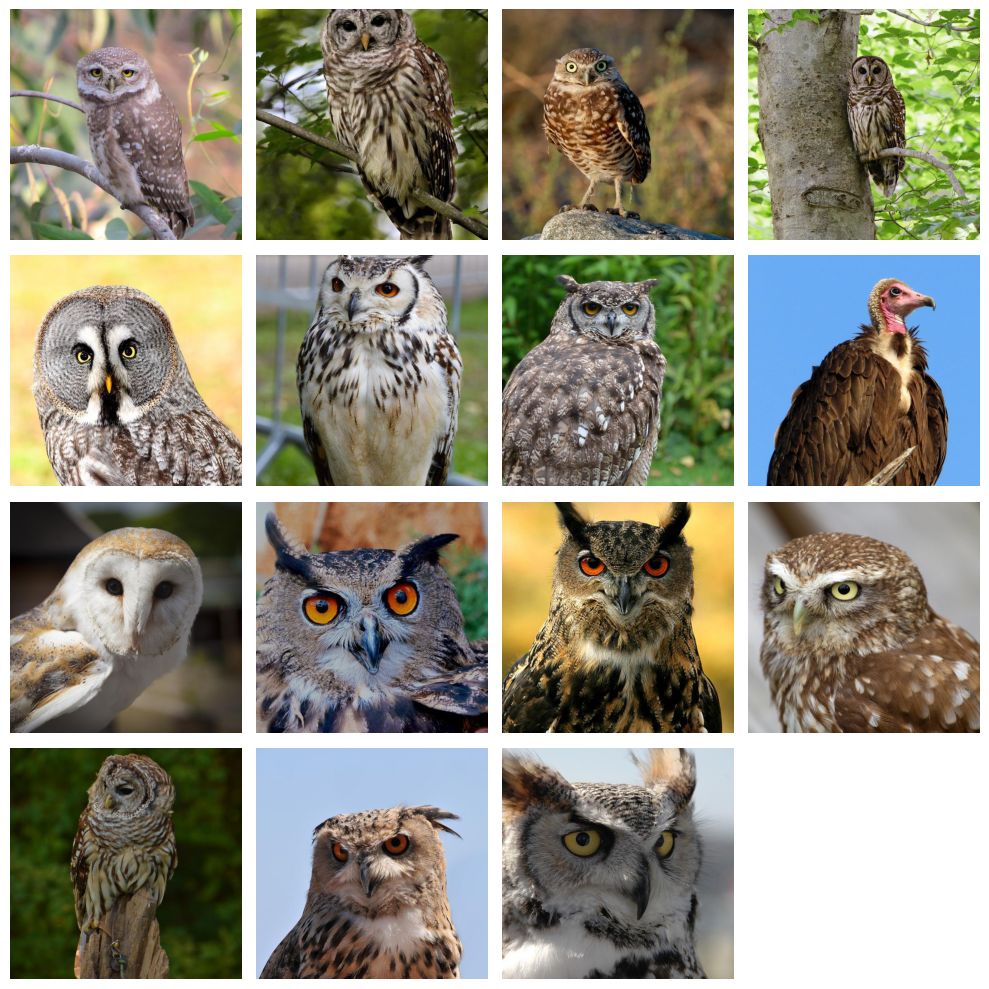

Pixel cluster:


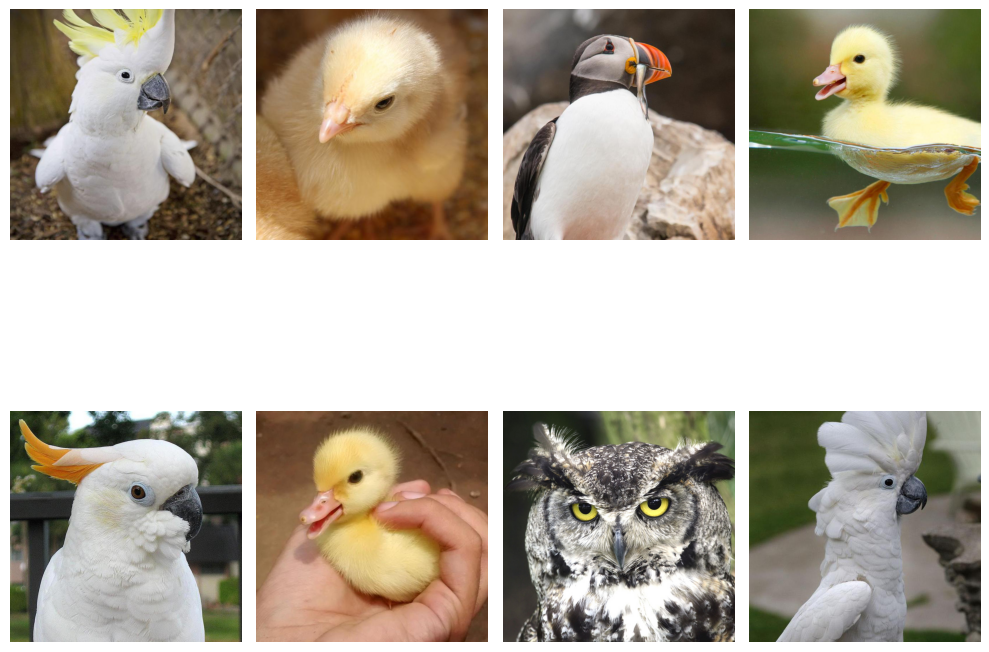

In [27]:
# example clusters
clip_k = 10      # Pick any valid cluster number from clip clusters (1 to 20).
pixel_k = 9    # Pick any valid cluster number from pixel clusters (1 to 16).

print("CLIP cluster:")
show_cluster_samples(birds, clip_clusters, clip_k, n=15)

print("Pixel cluster:")
show_cluster_samples(birds, pixel_clusters, pixel_k, n=15)


CLIP cluster:


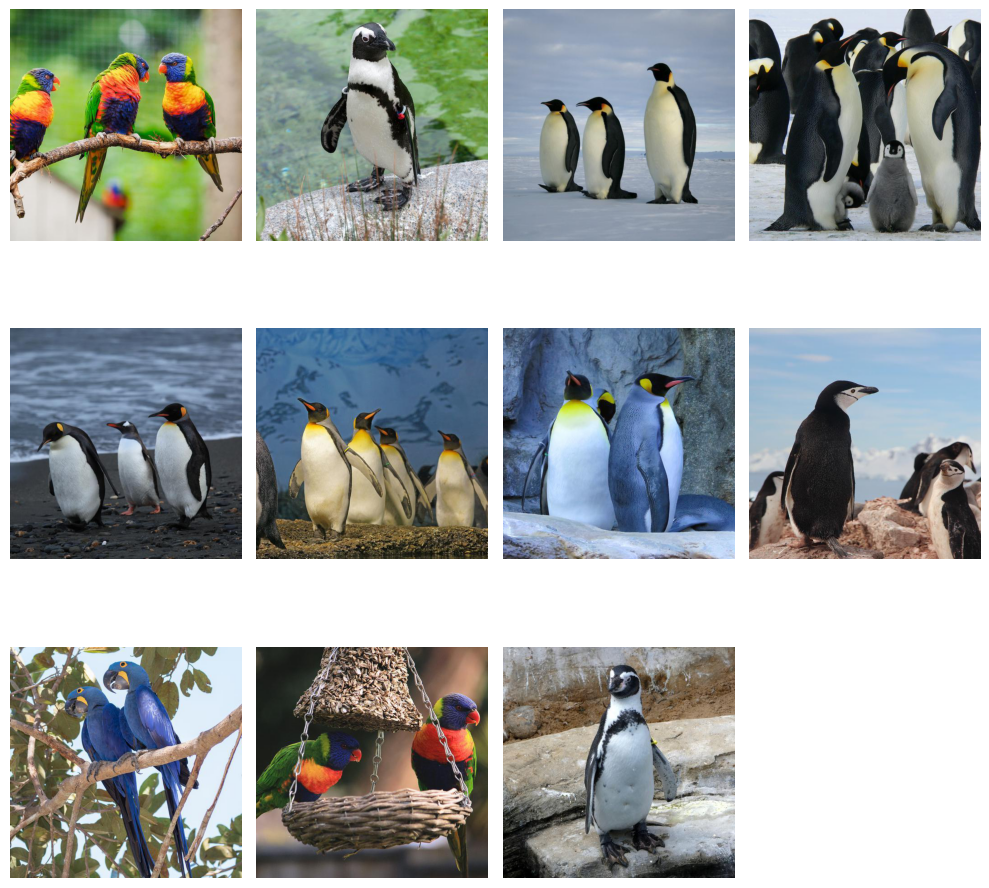

Pixel cluster:


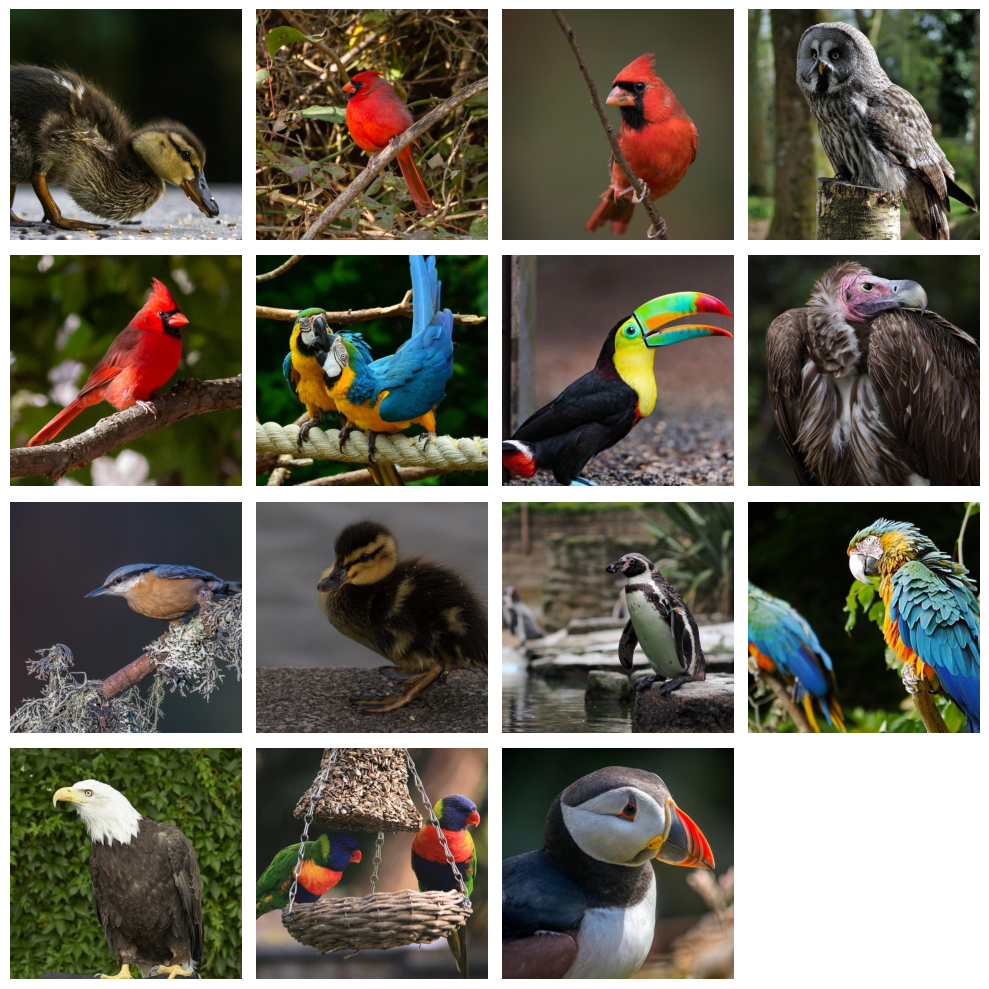

In [28]:
# example clusters
clip_k = 5      # Pick any valid cluster number from clip clusters.
pixel_k = 7    # Pick any valid cluster number from pixel clusters.

print("CLIP cluster:")
show_cluster_samples(birds, clip_clusters, clip_k, n=15)

print("Pixel cluster:")
show_cluster_samples(birds, pixel_clusters, pixel_k, n=15)


CLIP cluster:
cluster empty
Pixel cluster:


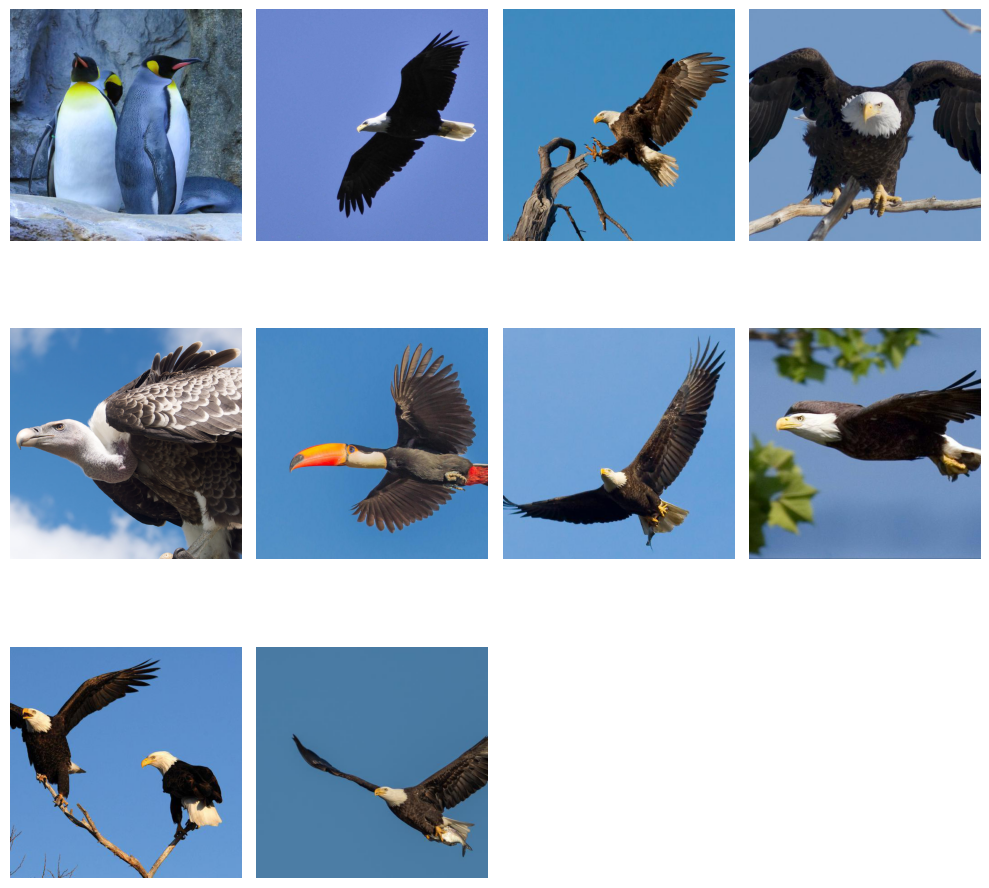

In [29]:
# example clusters
clip_k = 18     # Pick any valid cluster number from clip clusters (1 to 20).
pixel_k = 3    # Pick any valid cluster number from pixel clusters (1 to 10).

print("CLIP cluster:")
show_cluster_samples(birds, clip_clusters, clip_k, n=15)

print("Pixel cluster:")
show_cluster_samples(birds, pixel_clusters, pixel_k, n=15)


CLIP cluster:


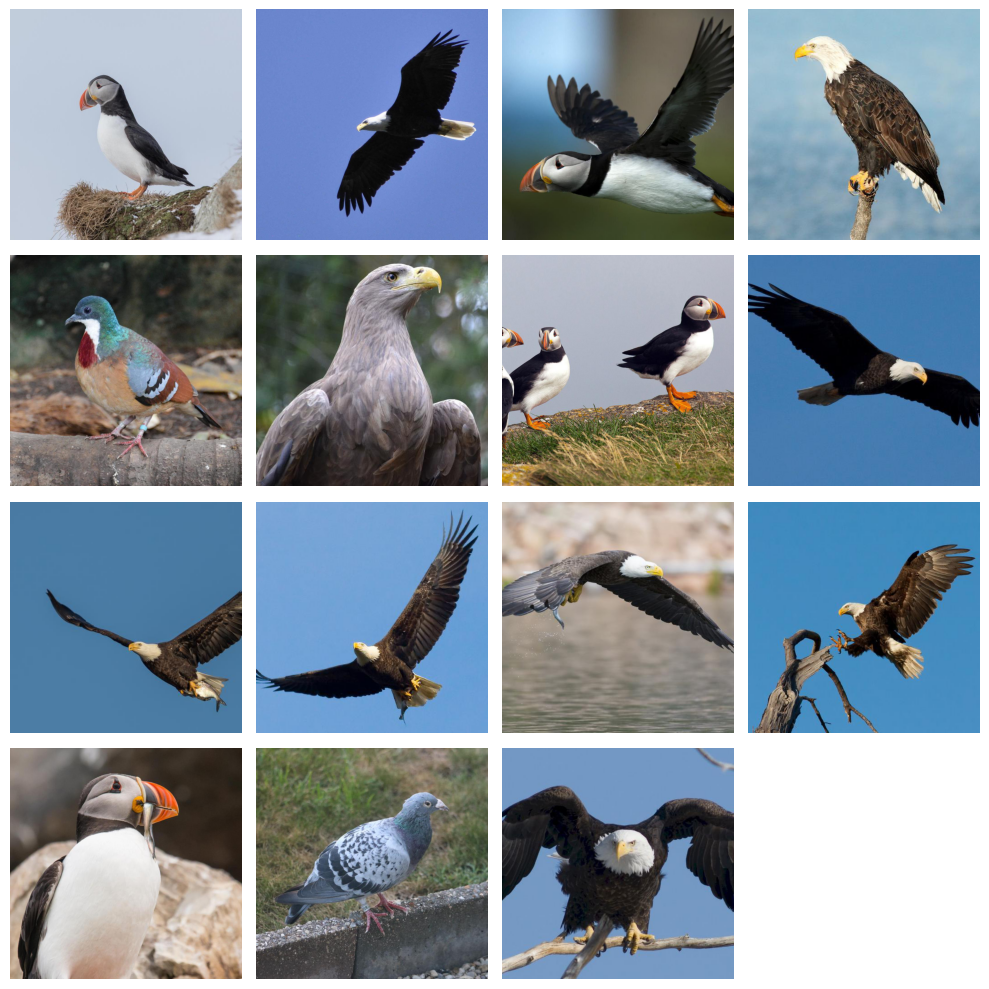

Pixel cluster:


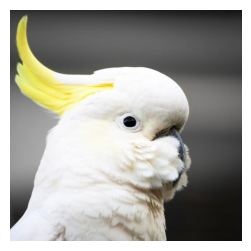

In [30]:
# example clusters
clip_k = 7    # Pick any valid cluster number from clip clusters (1 to 20).
pixel_k = 15    # Pick any valid cluster number from pixel clusters (1 to 10).

print("CLIP cluster:")
show_cluster_samples(birds, clip_clusters, clip_k, n=15)

print("Pixel cluster:")
show_cluster_samples(birds, pixel_clusters, pixel_k, n=15)


## Observations

We looked at several clusters from both the CLIP‑based clustering and the pixel‑based clustering to see how the images were grouped. We have displayed 4 such cluster pairs above. <br>
Overall, the CLIP clusters grouped together birds that looked similar in terms of species and shape. <br>
In contrast, the pixel clusters grouped images more randomly with a variety of birds being grouped together. The images could be similar on more hgih-level features of the images like the most dominant colors in them or the lighting and brightness in the images. <br>
It appears that CLIP clustering captured more meaningful bird similarities, while pixel clustering was mostly influenced by low‑level visual details.